# 一段階検出器（One-stage Detector）

Two-stage検出器は「候補領域の提案」と「分類・回帰」を分けることで高精度を実現する一方、候補領域ごとの処理が必要なため速度に限界があった。**One-stage（一段階）検出器** は、候補領域の提案という段階を明示的には設けず、画像全体に対する1回の forward だけで、あらかじめ用意した多数の位置・サイズの候補（グリッドセル or アンカー）すべてに対してクラス・ボックスを直接予測する。

構造がシンプルになる分、一般に推論速度が速く、精度はTwo-stage系よりやや劣る傾向にあった（この精度差は後年のバージョンアップで大きく縮まっている）。代表例として **YOLO** と **SSD** を扱う。

## YOLO（You Only Look Once）

[Redmon et al. (2016), You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640)

### 基本アイデア：グリッドベースの予測

YOLOは入力画像を $S \times S$ のグリッドに分割する（原論文では $S=7$）。物体の中心が属するグリッドセルが、その物体の検出を「担当」する。

各グリッドセルは

- $B$ 個のバウンディングボックス候補（各ボックスにつき $(x, y, w, h, \mathrm{confidence})$ の5値）
- $C$ 個のクラスに対する条件付きクラス確率 $P(\mathrm{class}_c \mid \mathrm{object})$

を予測する。したがって出力テンソルの形状は $S \times S \times (B \times 5 + C)$ になる。

confidenceは「そのボックスに物体が存在する確率」と「予測ボックスと正解ボックスのIoU」の積として定義される：

$$
\mathrm{confidence} = P(\mathrm{object}) \times \mathrm{IoU}(\mathrm{pred}, \mathrm{gt})
$$

推論時は、クラス確率とconfidenceを掛け合わせた **class-specific confidence score** を計算し、閾値以下を除去したうえでNMSを適用する。

$$
P(\mathrm{class}_c \mid \mathrm{object}) \times P(\mathrm{object}) \times \mathrm{IoU} = P(\mathrm{class}_c) \times \mathrm{IoU}
$$

### 損失関数

YOLOの損失は、位置回帰・confidence・クラス分類をすべて2乗誤差の重み付き和として扱う点が特徴的（多クラス分類でも softmax + cross entropy ではなく sum-squared error を使う）。

$$
\begin{aligned}
L = \; & \lambda_{\mathrm{coord}} \sum_{i,j} \mathbb{1}_{ij}^{\mathrm{obj}} \left[ (x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2 \right] \\
+ \; & \lambda_{\mathrm{coord}} \sum_{i,j} \mathbb{1}_{ij}^{\mathrm{obj}} \left[ (\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2 \right] \\
+ \; & \sum_{i,j} \mathbb{1}_{ij}^{\mathrm{obj}} (C_i - \hat{C}_i)^2
 + \lambda_{\mathrm{noobj}} \sum_{i,j} \mathbb{1}_{ij}^{\mathrm{noobj}} (C_i - \hat{C}_i)^2 \\
+ \; & \sum_i \mathbb{1}_i^{\mathrm{obj}} \sum_{c} (p_i(c) - \hat{p}_i(c))^2
\end{aligned}
$$

- $\mathbb{1}_{ij}^{\mathrm{obj}}$：グリッドセル$i$の$j$番目のボックスが物体の検出を担当するとき1
- 幅・高さの誤差を $\sqrt{w}, \sqrt{h}$ で扱うのは、大きい物体の多少の誤差より小さい物体の誤差を相対的に重視するため
- $\lambda_{\mathrm{coord}}=5$、$\lambda_{\mathrm{noobj}}=0.5$ として、物体を含まないセルの寄与を抑えつつ位置回帰を重視する（グリッドセルの大半は背景であるため）

### 課題とその後の発展

- 1グリッドセルにつき担当できる物体は基本的に1つ（$B$個のボックスは同じクラスを予測する設計）なので、密集した小物体の検出が苦手
- **YOLOv2 / YOLO9000**（[Redmon & Farhadi, 2017](https://arxiv.org/abs/1612.08242)）：Faster R-CNNのようにアンカーボックスを導入し、グリッドセルごとに複数クラス・複数アンカーを扱えるようにして再現率を改善
- **YOLOv3**（[Redmon & Farhadi, 2018](https://arxiv.org/abs/1804.02767)）：FPN的な発想で3つのスケールの特徴マップで予測し、多クラスを扱うためsoftmaxではなく独立したロジスティック回帰（クラスごとの2値分類）を採用
- **YOLOv4以降 / YOLOv5, v8, v11...**：Ultralytics社などによる実装・改良が続き、CSPNet・PANet・Anchor-freeヘッド・NMS-free化など、Two-stage系や後述のFCOS・DETR系のアイデアも取り込みながら発展を続けている（バージョンごとの詳細は本ノートでは扱わない）

## SSD（Single Shot MultiBox Detector）

[Liu et al. (2016), SSD: Single Shot MultiBox Detector](https://arxiv.org/abs/1512.02325)

SSDもYOLOと同様に1回のforwardで検出を行うが、以下の点で異なる設計を採用している。

### マルチスケール特徴マップ

SSDはバックボーンCNN（VGG16）の後段に、解像度が段階的に小さくなる複数の畳み込み層を追加し、**それぞれの解像度の特徴マップで独立に検出を行う**。浅い層（高解像度）は小さい物体、深い層（低解像度）は大きい物体の検出を担当する。これにより、YOLOv1が苦手としていた多様なスケールの物体に対応しやすくなる。

### デフォルトボックス（Default Box）

各特徴マップの各セルに、Faster R-CNNのアンカーに相当する **デフォルトボックス** を複数（スケール・アスペクト比違い）配置する。学習時は各デフォルトボックスと正解ボックスのIoUに基づいてマッチングを行い（IoU閾値、例えば $0.5$ 以上で正例とする）、位置オフセットとクラスを回帰・分類する。

### Hard Negative Mining

1枚の画像あたりのデフォルトボックス数は数千〜数万に及び、そのほとんどは背景（負例）になる。正例・負例の不均衡を緩和するため、SSDは全ての負例を使わず、confidence lossが大きい（＝モデルが間違えやすい）負例を優先的にサンプリングして学習に使う（正例:負例 を概ね $1:3$ 程度に保つ）。

### YOLOとの違いのまとめ

| | YOLO (v1) | SSD |
| --- | --- | --- |
| 予測を行う特徴マップ | 単一スケール（$S\times S$グリッド） | 複数スケール |
| ボックスの基準 | グリッドセル中心からの直接回帰 | デフォルトボックスからのオフセット回帰（アンカーベース） |
| 小物体への対応 | 弱い（v1時点） | マルチスケールによりv1より強い |

## 実行例：SSD による推論

`torchvision` の COCO 事前学習済み SSD（SSD300, VGG16バックボーン）でサンプル画像を検出する。

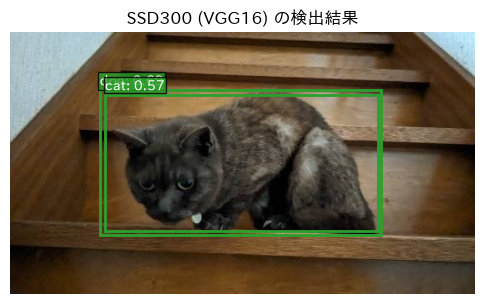

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib_fontja
import torch
from PIL import Image
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights

weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights)
model.eval()
categories = weights.meta["categories"]

img = Image.open("../sample_images/cat2.jpg").convert("RGB")
x = weights.transforms()(img)

with torch.no_grad():
    output = model([x])[0]

score_threshold = 0.5
fig, ax = plt.subplots(figsize=[6, 4])
ax.imshow(img)
for box, label, score in zip(output["boxes"], output["labels"], output["scores"]):
    if score < score_threshold:
        continue
    x0, y0, x1, y1 = box.tolist()
    ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="tab:green", facecolor="none"))
    ax.text(x0, y0 - 5, f"{categories[label]}: {score:.2f}", color="white",
            bbox=dict(facecolor="tab:green", alpha=0.8, pad=1))
ax.set_title("SSD300 (VGG16) の検出結果")
ax.axis("off")
plt.show()

## 参考文献

- Redmon, J. et al. (2016). [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640)
- Redmon, J. & Farhadi, A. (2017). [YOLO9000: Better, Faster, Stronger](https://arxiv.org/abs/1612.08242)
- Redmon, J. & Farhadi, A. (2018). [YOLOv3: An Incremental Improvement](https://arxiv.org/abs/1804.02767)
- Liu, W. et al. (2016). [SSD: Single Shot MultiBox Detector](https://arxiv.org/abs/1512.02325)
- [torchvision.models.detection.ssd300_vgg16 — Torchvision documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.ssd300_vgg16.html)